# Deteccao de Anomalias em Turbinas Eolicas com CNN-LSTM Autoencoder (v2)
## Wind Farm C -- Dados SCADA

Pipeline completo para deteccao de anomalias em turbinas eolicas offshore utilizando
dados SCADA com resolucao de 10 minutos. O fluxo inclui pre-processamento, selecao
de features via XGBoost, treinamento de um autoencoder CNN-LSTM em PyTorch e avaliacao
quantitativa da deteccao de falhas.

### Melhorias em relacao a v1
- Dropout reduzido (0.5 -> 0.15) para melhor capacidade de reconstrucao
- Batch size aumentado (32 -> 128) para treinamento mais eficiente
- Learning rate scheduler (ReduceLROnPlateau) para convergencia adaptativa
- XGBoost com `scale_pos_weight` para melhor selecao de features em dados desbalanceados
- Normalizacao sem clipping forcado, com diagnostico de valores fora de range
- Threshold otimizado via curva Precision-Recall (alem de P95/P99)
- Metricas AUC-ROC e AUC-PR para avaliacao independente de threshold
- Avaliacao por evento de anomalia (taxa de deteccao por evento)
- Codigo de debug removido

In [1]:
import os
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, auc
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

BASE_DIR = os.path.join('CARE_To_Compare', 'Wind Farm C')
DATASETS_DIR = os.path.join(BASE_DIR, 'datasets')
EVENT_INFO_PATH = os.path.join(BASE_DIR, 'event_info.csv')
FEATURE_DESC_PATH = os.path.join(BASE_DIR, 'feature_description.csv')
OUTPUT_DIR = 'artefatos_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_SIZE = 36
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
FEATURE_TOP_PERCENT = 0.30
BATCH_SIZE = 128
EPOCHS = 10
PATIENCE = 5
LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.15

META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
HEALTHY_STATUS = [0, 2]

print(f"Janela temporal: {WINDOW_SIZE} steps ({WINDOW_SIZE * 10 / 60:.0f} horas)")
print(f"Split: {TRAIN_RATIO*100:.0f}% treino / {VAL_RATIO*100:.0f}% validacao / {TEST_RATIO*100:.0f}% teste")
print(f"Selecao de features: top {FEATURE_TOP_PERCENT*100:.0f}% (XGBoost)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Dropout: {DROPOUT_RATE}")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Dispositivo: cuda
Janela temporal: 36 steps (6 horas)
Split: 70% treino / 15% validacao / 15% teste
Selecao de features: top 30% (XGBoost)
Batch size: 128
Dropout: 0.15
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


## 1. Carregamento dos Dados

Carregamento de todos os 58 datasets CSV do Wind Farm C e do arquivo de informacoes
de eventos. Cada dataset contem series temporais SCADA de uma turbina com resolucao
de 10 minutos e ate 957 features (sensores com estatisticas avg, min, max, std).

In [2]:
event_info = pd.read_csv(EVENT_INFO_PATH, sep=';')
event_info['event_start'] = pd.to_datetime(event_info['event_start'])
event_info['event_end'] = pd.to_datetime(event_info['event_end'])

print(f"Total de eventos: {len(event_info)}")
print(f"  Anomalias: {(event_info['event_label'] == 'anomaly').sum()}")
print(f"  Normais:   {(event_info['event_label'] == 'normal').sum()}")
print(f"  Turbinas unicas: {event_info['asset_id'].nunique()}")
event_info.head(10)

Total de eventos: 58
  Anomalias: 27
  Normais:   31
  Turbinas unicas: 22


,asset_id,event_id,event_label,event_start,event_start_id,event_end,event_end_id,event_description
0,50,55,anomaly,2023-10-29 11:30:00,52848,2023-11-15 15:30:00,55320,Harting plug Nacelle/HUB damaged + NCR20_HUB: ...
1,38,81,anomaly,2023-11-16 01:30:00,52704,2023-11-18 14:00:00,53067,Converter Failure from 17.11 12:30 - 18.11. 13...
2,21,47,anomaly,2023-12-22 15:00:00,52416,2023-12-27 13:40:00,53128,Failure due to Rotorbrake and Hydraulic proble...
3,2,12,anomaly,2023-06-27 00:00:00,52560,2023-07-19 15:00:00,55818,"10115 : Oil level error, two-pump mode + Oil L..."
4,34,4,anomaly,2023-07-31 10:00:00,52992,2023-08-19 10:00:00,55728,23020 : Axis 3 not ready-to-operate
5,34,18,anomaly,2023-09-13 00:00:00,51408,2023-09-16 23:50:00,51983,We had some failures (störung 24VAC Versorgung...
6,52,28,anomaly,2023-05-28 13:00:00,52704,2023-06-17 20:30:00,55629,P20_spinner_carbonbrush defekt + P20_Accumulat...
7,52,39,anomaly,2023-10-19 13:00:00,52848,2023-10-24 15:20:00,53582,15004 : Safety chain relay open + 93005 : Gear...
8,12,66,anomaly,2023-01-17 00:00:00,51696,2023-01-23 13:00:00,52638,"Pitchfailure - defect Beckhoffcard, Axis 2, re..."
9,12,15,anomaly,2023-02-06 00:00:00,51984,2023-02-23 00:00:00,54432,Randomn small failures regarding pitch resulti...


In [3]:
csv_files = sorted([f for f in os.listdir(DATASETS_DIR) if f.endswith('.csv')])
print(f"Total de arquivos CSV: {len(csv_files)}")

print("Passo 1: coletando timestamps para definir cortes do split temporal...")
all_ts = []
for csv_file in csv_files:
    ts = pd.read_csv(os.path.join(DATASETS_DIR, csv_file),
                     sep=';', usecols=['time_stamp'])['time_stamp']
    all_ts.append(pd.to_datetime(ts))

all_ts = pd.concat(all_ts).sort_values().reset_index(drop=True)
n_total = len(all_ts)
ts_train_cutoff = all_ts.iloc[int(n_total * TRAIN_RATIO)]
ts_val_cutoff   = all_ts.iloc[int(n_total * (TRAIN_RATIO + VAL_RATIO))]
del all_ts; gc.collect()

print(f"  Amostras totais: {n_total:,}")
print(f"  Corte treino/val: {ts_train_cutoff}")
print(f"  Corte val/teste:  {ts_val_cutoff}")

sample_header = pd.read_csv(os.path.join(DATASETS_DIR, csv_files[0]), sep=';', nrows=0)
scols_all = [c for c in sample_header.columns if c not in META_COLS]
dtype_map = {c: np.float32 for c in scols_all}

print("\nPasso 2: processamento por arquivo (ffill + labeling + split)...")
anomaly_dict = {}
for _, row in event_info[event_info['event_label'] == 'anomaly'].iterrows():
    anomaly_dict[row['event_id']] = (row['event_start'], row['event_end'])

train_parts, val_parts, test_parts = [], [], []

for i, csv_file in enumerate(csv_files):
    event_id = int(csv_file.replace('.csv', ''))
    filepath = os.path.join(DATASETS_DIR, csv_file)

    df = pd.read_csv(filepath, sep=';', dtype=dtype_map)
    df['event_id'] = event_id
    df['time_stamp'] = pd.to_datetime(df['time_stamp'])

    scols = [c for c in df.columns if c not in META_COLS + ['event_id']]
    df[scols] = df[scols].ffill()
    df[scols] = df[scols].bfill()

    df['label'] = 0
    if event_id in anomaly_dict:
        es, ee = anomaly_dict[event_id]
        mask_anom = (df['time_stamp'] >= es) & (df['time_stamp'] <= ee)
        df.loc[mask_anom, 'label'] = 1

    df['is_healthy'] = (
        (df['label'] == 0) & df['status_type_id'].isin(HEALTHY_STATUS)
    ).astype(np.int8)

    m_tr = df['time_stamp'] < ts_train_cutoff
    m_va = (df['time_stamp'] >= ts_train_cutoff) & (df['time_stamp'] < ts_val_cutoff)
    m_te = df['time_stamp'] >= ts_val_cutoff

    if m_tr.any(): train_parts.append(df.loc[m_tr])
    if m_va.any(): val_parts.append(df.loc[m_va])
    if m_te.any(): test_parts.append(df.loc[m_te])

    del df
    if (i + 1) % 10 == 0:
        gc.collect()
    if (i + 1) % 20 == 0 or (i + 1) == len(csv_files):
        print(f"  Processados: {i + 1}/{len(csv_files)}")

print("\nConcatenando e ordenando splits...")

df_train = pd.concat(train_parts, ignore_index=True)
del train_parts; gc.collect()
df_train.sort_values('time_stamp', inplace=True)
df_train.reset_index(drop=True, inplace=True)

df_val = pd.concat(val_parts, ignore_index=True)
del val_parts; gc.collect()
df_val.sort_values('time_stamp', inplace=True)
df_val.reset_index(drop=True, inplace=True)

df_test = pd.concat(test_parts, ignore_index=True)
del test_parts; gc.collect()
df_test.sort_values('time_stamp', inplace=True)
df_test.reset_index(drop=True, inplace=True)

n = len(df_train) + len(df_val) + len(df_test)
for name, sp in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    ns = len(sp)
    mem = sp.memory_usage(deep=True).sum() / 1e6
    print(f"  {name:10s}: {ns:>7,} amostras ({ns/n*100:5.1f}%) | "
          f"Anomalias: {(sp['label']==1).sum():>5,} | "
          f"Saudaveis: {(sp['is_healthy']==1).sum():>7,} | "
          f"Mem: {mem:,.0f} MB")

Total de arquivos CSV: 58
Passo 1: coletando timestamps para definir cortes do split temporal...
  Amostras totais: 3,187,136
  Corte treino/val: 2023-04-15 11:40:00
  Corte val/teste:  2023-07-08 20:10:00

Passo 2: processamento por arquivo (ffill + labeling + split)...
  Processados: 20/58
  Processados: 40/58
  Processados: 58/58

Concatenando e ordenando splits...
  Treino    : 2,230,956 amostras ( 70.0%) | Anomalias: 14,133 | Saudaveis: 1,994,546 | Mem: 8,725 MB
  Validacao : 478,082 amostras ( 15.0%) | Anomalias: 4,631 | Saudaveis: 414,795 | Mem: 1,870 MB
  Teste     : 478,098 amostras ( 15.0%) | Anomalias: 42,133 | Saudaveis: 386,050 | Mem: 1,870 MB


## 2. Rotulacao (Labeling)

Criacao de labels binarios para cada amostra:
- **0 (saudavel)**: timestamp fora de qualquer periodo de anomalia
- **1 (anomalia)**: timestamp dentro do periodo `[event_start, event_end]` de um evento
  classificado como anomalia no `event_info.csv`

Adicionalmente, definimos o conceito de amostra **estritamente saudavel** como aquela
com `label=0` e `status_type_id` em {0 (operacao normal), 2 (idling)}. Somente estas
amostras serao usadas para treinar o autoencoder, garantindo que o modelo aprenda
exclusivamente o comportamento normal da turbina.

In [4]:
all_labels = pd.concat([df_train['label'], df_val['label'], df_test['label']])
all_healthy = pd.concat([df_train['is_healthy'], df_val['is_healthy'], df_test['is_healthy']])
all_status = pd.concat([df_train['status_type_id'], df_val['status_type_id'], df_test['status_type_id']])

print("Distribuicao de labels (todos os splits combinados):")
print(f"  Saudavel (0):  {(all_labels == 0).sum():,} "
      f"({(all_labels == 0).mean()*100:.1f}%)")
print(f"  Anomalia (1):  {(all_labels == 1).sum():,} "
      f"({(all_labels == 1).mean()*100:.1f}%)")
print(f"\nAmostras estritamente saudaveis (label=0 e status normal/idling): "
      f"{(all_healthy == 1).sum():,} ({(all_healthy == 1).mean()*100:.1f}%)")
print(f"\nDistribuicao de status_type_id:")
print(all_status.value_counts().sort_index().to_string())
del all_labels, all_healthy, all_status

Distribuicao de labels (todos os splits combinados):
  Saudavel (0):  3,126,239 (98.1%)
  Anomalia (1):  60,897 (1.9%)

Amostras estritamente saudaveis (label=0 e status normal/idling): 2,795,391 (87.7%)

Distribuicao de status_type_id:
status_type_id
0    2843548
3     246764
4      20036
5      76788


## 3. Divisao Temporal dos Dados

Divisao estritamente temporal (70% treino / 15% validacao / 15% teste) baseada na
ordenacao global por timestamp. Em series temporais, a divisao aleatoria e proibida
pois causa vazamento de informacao temporal (data leakage).

O scaler e o XGBoost serao ajustados **somente** nos dados de treino.

In [5]:
n = len(df_train) + len(df_val) + len(df_test)

print("Verificacao da divisao temporal (ja realizada na etapa de carregamento):\n")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    n_total = len(split)
    n_anom = (split['label'] == 1).sum()
    n_healthy = (split['is_healthy'] == 1).sum()
    print(f"{name:10s}: {n_total:>7,} amostras ({n_total/n*100:5.1f}%) | "
          f"Anomalias: {n_anom:>5,} | Saudaveis: {n_healthy:>7,} | "
          f"Periodo: {split['time_stamp'].min()} -- {split['time_stamp'].max()}")

print(f"\nCorte treino/val: {ts_train_cutoff}")
print(f"Corte val/teste:  {ts_val_cutoff}")

Verificacao da divisao temporal (ja realizada na etapa de carregamento):

Treino    : 2,230,956 amostras ( 70.0%) | Anomalias: 14,133 | Saudaveis: 1,994,546 | Periodo: 2022-01-06 00:00:00 -- 2023-04-15 11:30:00
Validacao : 478,082 amostras ( 15.0%) | Anomalias: 4,631 | Saudaveis: 414,795 | Periodo: 2023-04-15 11:40:00 -- 2023-07-08 20:00:00
Teste     : 478,098 amostras ( 15.0%) | Anomalias: 42,133 | Saudaveis: 386,050 | Periodo: 2023-07-08 20:10:00 -- 2024-01-08 15:40:00

Corte treino/val: 2023-04-15 11:40:00
Corte val/teste:  2023-07-08 20:10:00


## 4. Normalizacao dos Dados

Normalizacao Min-Max para o intervalo [0, 1] aplicada a todas as features de sensores.
O scaler e ajustado **exclusivamente** nos dados de treino para evitar vazamento de
informacao (data leakage). Os conjuntos de validacao e teste sao transformados com
os parametros aprendidos no treino.

**Melhoria v2**: sem clipping forcado -- valores fora de [0, 1] sao preservados e
diagnosticados, pois podem indicar data drift ou distribuicoes diferentes entre splits.

In [6]:
sensor_cols = [c for c in df_train.columns
              if c not in META_COLS + ['event_id', 'label', 'is_healthy']]
print(f"Total de features de sensores: {len(sensor_cols)}")

scaler = MinMaxScaler(feature_range=(0, 1))
CHUNK_FIT = 50_000
for start in range(0, len(df_train), CHUNK_FIT):
    end = min(start + CHUNK_FIT, len(df_train))
    scaler.partial_fit(df_train[sensor_cols].iloc[start:end])

print("Scaler ajustado via partial_fit (sem converter tudo para float64)")

scale_ = scaler.scale_.astype(np.float32)
min_   = scaler.min_.astype(np.float32)

for split_name, df_split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    n_oor = 0
    for i, col in enumerate(sensor_cols):
        vals = df_split[col].values * scale_[i] + min_[i]
        out_of_range = int(((vals < 0) | (vals > 1)).sum())
        n_oor += out_of_range
        df_split[col] = vals
    gc.collect()
    n_total_vals = len(df_split) * len(sensor_cols)
    print(f"  {split_name} normalizado | Valores fora de [0,1]: {n_oor:,} "
          f"({n_oor/n_total_vals*100:.4f}%)")

del scale_, min_; gc.collect()

print("\nNormalizacao concluida (MinMaxScaler ajustado somente no treino, sem clipping)")
for name, split in [('Treino', df_train), ('Validacao', df_val), ('Teste', df_test)]:
    vals = split[sensor_cols]
    print(f"  {name:10s} - min: {vals.min().min():.4f}, "
          f"max: {vals.max().max():.4f}, media: {vals.mean().mean():.4f}")

Total de features de sensores: 952
Scaler ajustado via partial_fit (sem converter tudo para float64)
  Treino normalizado | Valores fora de [0,1]: 35,340 (0.0017%)
  Validacao normalizado | Valores fora de [0,1]: 104,199 (0.0229%)
  Teste normalizado | Valores fora de [0,1]: 241,002 (0.0530%)

Normalizacao concluida (MinMaxScaler ajustado somente no treino, sem clipping)
  Treino     - min: 0.0000, max: 1.0000, media: 0.4021
  Validacao  - min: -55.5373, max: 109.0334, media: 0.3945
  Teste      - min: -2.8030, max: 15.8398, media: 0.4075


## 5. Selecao de Features com XGBoost

Utilizacao do XGBoost para classificacao binaria (saudavel vs anomalia) nos dados de
treino. As features sao rankeadas por importancia (`feature_importances_`) e as top
30% sao selecionadas, reduzindo a dimensionalidade e mantendo as variaveis mais
relevantes para a deteccao de falhas.

**Melhoria v2**: `scale_pos_weight` calculado automaticamente a partir do ratio de
desbalanceamento das classes, garantindo que a classe minoritaria (anomalia) tenha
peso proporcional na selecao de features.

In [ ]:
MAX_XGB_SAMPLES = 200_000
if len(df_train) > MAX_XGB_SAMPLES:
    rng = np.random.RandomState(SEED)
    sample_idx = rng.choice(len(df_train), MAX_XGB_SAMPLES, replace=False)
    sample_idx.sort()
    X_train_xgb = df_train[sensor_cols].iloc[sample_idx].values
    y_train_xgb = df_train['label'].iloc[sample_idx].values
    print(f"Subamostra para XGBoost: {MAX_XGB_SAMPLES:,} de {len(df_train):,}")
else:
    X_train_xgb = df_train[sensor_cols].values
    y_train_xgb = df_train['label'].values

neg_count = int((y_train_xgb == 0).sum())
pos_count = int((y_train_xgb == 1).sum())
spw = neg_count / max(pos_count, 1)

print(f"Treinando XGBoost: {X_train_xgb.shape[0]:,} amostras, {X_train_xgb.shape[1]} features")
print(f"  Classes: 0={neg_count:,}  1={pos_count:,}")
print(f"  scale_pos_weight: {spw:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=SEED,
    eval_metric='logloss',
    n_jobs=-1
)  
xgb_model.fit(X_train_xgb, y_train_xgb)

importances = xgb_model.feature_importances_.copy()
feature_importance_df = pd.DataFrame({
    'feature': sensor_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

n_selected = max(1, int(len(sensor_cols) * FEATURE_TOP_PERCENT))
selected_features = feature_importance_df.head(n_selected)['feature'].tolist()

print(f"\nFeatures originais: {len(sensor_cols)}")
print(f"Features selecionadas (top {FEATURE_TOP_PERCENT*100:.0f}%): {n_selected}")
print(f"\nTop 20 features mais importantes:")
print(feature_importance_df.head(20).to_string())

del X_train_xgb, y_train_xgb; gc.collect()

Subamostra para XGBoost: 200,000 de 2,230,956
Treinando XGBoost: 200,000 amostras, 952 features
  Classes: 0=198,756  1=1,244
  scale_pos_weight: 159.77

Features originais: 952
Features selecionadas (top 30%): 285

Top 20 features mais importantes:
               feature  importance
0        sensor_93_avg    0.227554
1        sensor_74_avg    0.121186
2        sensor_74_min    0.101618
3       sensor_126_avg    0.059914
4       sensor_110_avg    0.050187
5        sensor_64_min    0.040206
6       sensor_218_max    0.013568
7        sensor_69_avg    0.012780
8       sensor_203_avg    0.011966
9       sensor_179_avg    0.011873
10      sensor_210_min    0.011277
11       sensor_62_min    0.011183
12      sensor_210_avg    0.010914
13      sensor_108_avg    0.010735
14       sensor_34_std    0.008629
15      sensor_231_max    0.006956
16       sensor_55_min    0.006735
17  wind_speed_235_max    0.006589
18      sensor_193_avg    0.006262
19       sensor_71_max    0.006115


40

In [8]:
keep_cols = ['time_stamp', 'event_id', 'label', 'is_healthy']
df_train_sel = df_train[keep_cols + selected_features].copy()
df_val_sel = df_val[keep_cols + selected_features].copy()
df_test_sel = df_test[keep_cols + selected_features].copy()

del df_train, df_val, df_test
gc.collect()

print("Dimensao apos selecao de features:")
print(f"  Treino:    {df_train_sel.shape}")
print(f"  Validacao: {df_val_sel.shape}")
print(f"  Teste:     {df_test_sel.shape}")

Dimensao apos selecao de features:
  Treino:    (2230956, 289)
  Validacao: (478082, 289)
  Teste:     (478098, 289)


## 6. Criacao de Janelas Temporais

Criacao de janelas deslizantes de 36 timesteps (equivalente a 6 horas com dados de
10 em 10 minutos). As janelas sao construidas **dentro de cada dataset** (mesmo
`event_id`) para nao misturar dados de diferentes turbinas ou eventos.

- **Janela saudavel**: todos os 36 timesteps possuem `is_healthy=1`
- **Janela com anomalia**: pelo menos 1 timestep possui `label=1`

In [9]:
def build_window_index(df, window_size, feature_cols):
    """Build per-group flat arrays and window metadata without materializing windows.

    Instead of storing an (N, W, F) tensor (~91 GB for training), we keep the
    flat feature arrays per event_id and a compact index of (eid, start, label,
    healthy) per window.  Windows are constructed on-the-fly in WindowDataset.
    """
    group_arrays = {}
    all_eid, all_start, all_label, all_healthy = [], [], [], []

    for eid, group in df.groupby('event_id'):
        group = group.sort_values('time_stamp').reset_index(drop=True)
        group_arrays[eid] = group[feature_cols].values.astype(np.float32)
        labels  = group['label'].values.astype(np.int8)
        healthy = group['is_healthy'].values.astype(np.int8)

        n = len(group)
        if n < window_size:
            continue

        nw = n - window_size + 1
        cum_l = np.concatenate([[0], np.cumsum(labels)])
        cum_h = np.concatenate([[0], np.cumsum(healthy)])
        w_labels  = (cum_l[window_size:] - cum_l[:nw] > 0).astype(np.int8)
        w_healthy = (cum_h[window_size:] - cum_h[:nw] == window_size).astype(np.int8)

        all_eid.append(np.full(nw, eid, dtype=np.int32))
        all_start.append(np.arange(nw, dtype=np.int32))
        all_label.append(w_labels)
        all_healthy.append(w_healthy)

    return (group_arrays,
            np.concatenate(all_eid),
            np.concatenate(all_start),
            np.concatenate(all_label),
            np.concatenate(all_healthy))


class WindowDataset(torch.utils.data.Dataset):
    """Memory-efficient dataset: builds each window on-the-fly from flat arrays."""
    def __init__(self, group_arrays, eids, starts, window_size):
        self.ga     = group_arrays
        self.eids   = eids
        self.starts = starts
        self.ws     = window_size

    def __len__(self):
        return len(self.eids)

    def __getitem__(self, idx):
        e = int(self.eids[idx])
        s = int(self.starts[idx])
        return torch.from_numpy(self.ga[e][s:s + self.ws].copy())


ga_train, eid_tr, start_tr, y_train, h_train = build_window_index(
    df_train_sel, WINDOW_SIZE, selected_features)
del df_train_sel; gc.collect()

ga_val, eid_va, start_va, y_val, h_val = build_window_index(
    df_val_sel, WINDOW_SIZE, selected_features)
del df_val_sel; gc.collect()

ga_test, eid_te, start_te, y_test, h_test = build_window_index(
    df_test_sel, WINDOW_SIZE, selected_features)
del df_test_sel; gc.collect()

n_features = len(selected_features)
print(f"Indices de janelas criados (window_size={WINDOW_SIZE}, features={n_features}):")
for name, eid_arr, y_arr, h_arr in [
    ('Treino', eid_tr, y_train, h_train),
    ('Validacao', eid_va, y_val, h_val),
    ('Teste', eid_te, y_test, h_test)]:
    print(f"  {name:10s}: {len(eid_arr):>7,} janelas | "
          f"Anomalias: {y_arr.sum():,} | Saudaveis: {h_arr.sum():,}")

ga_mem = sum(a.nbytes for a in ga_train.values()) / 1e9
print(f"\nMemoria: ~{ga_mem:.1f} GB (treino) vs ~{ga_mem * WINDOW_SIZE:.0f} GB "
      f"se janelas fossem materializadas")

Indices de janelas criados (window_size=36, features=285):
  Treino    : 2,228,926 janelas | Anomalias: 14,308 | Saudaveis: 1,569,517
  Validacao : 476,577 janelas | Anomalias: 4,666 | Saudaveis: 322,265
  Teste     : 476,838 janelas | Anomalias: 42,693 | Saudaveis: 299,120

Memoria: ~2.5 GB (treino) vs ~92 GB se janelas fossem materializadas


In [10]:
healthy_mask_tr = (h_train == 1)
healthy_mask_va = (h_val == 1)

n_healthy_tr = int(healthy_mask_tr.sum())
n_healthy_va = int(healthy_mask_va.sum())

print("Janelas saudaveis para treinamento do autoencoder:")
print(f"  Treino:    ({n_healthy_tr}, {WINDOW_SIZE}, {n_features})")
print(f"  Validacao: ({n_healthy_va}, {WINDOW_SIZE}, {n_features})")

print(f"\nDimensoes de entrada do modelo:")
print(f"  Timesteps:  {WINDOW_SIZE}")
print(f"  Features:   {n_features}")

Janelas saudaveis para treinamento do autoencoder:
  Treino:    (1569517, 36, 285)
  Validacao: (322265, 36, 285)

Dimensoes de entrada do modelo:
  Timesteps:  36
  Features:   285


## 7. Modelo CNN-LSTM Autoencoder (PyTorch)

Arquitetura do autoencoder projetada para aprender a representacao comprimida do
comportamento normal da turbina eolica.

**Encoder**: camadas convolucionais extraem padroes locais da serie temporal, seguidas
por camadas LSTM que capturam dependencias temporais de longo prazo, comprimindo a
informacao em um vetor latente.

**Decoder**: reconstroi a serie temporal original a partir do vetor latente, utilizando
LSTMs e camadas densas.

O modelo e treinado **exclusivamente** com dados saudaveis. Na inferencia, anomalias
geram erros de reconstrucao elevados, permitindo sua deteccao.

**Melhoria v2**: dropout reduzido de 0.5 para 0.15, parametrizado no construtor.

In [11]:
class CNNLSTMAutoencoder(nn.Module):
    def __init__(self, n_features, timesteps, dropout_rate=0.15):
        super().__init__()
        self.n_features = n_features
        self.timesteps = timesteps

        self.enc_conv1 = nn.Conv1d(n_features, 32, kernel_size=3)
        self.enc_pool1 = nn.MaxPool1d(2)
        self.enc_conv2 = nn.Conv1d(32, 64, kernel_size=2)
        self.enc_pool2 = nn.MaxPool1d(3)

        self.conv_out_len = ((timesteps - 2) // 2 - 1) // 3

        self.enc_lstm1 = nn.LSTM(64, 100, batch_first=True)
        self.enc_lstm2 = nn.LSTM(100, 80, batch_first=True)

        self.dec_lstm1 = nn.LSTM(80, 80, batch_first=True)
        self.dec_lstm2 = nn.LSTM(80, 100, batch_first=True)

        self.dropout = nn.Dropout(dropout_rate)
        self.dec_fc1 = nn.Linear(100, 50)
        self.dec_fc2 = nn.Linear(50, 10)
        self.dec_fc3 = nn.Linear(10, n_features)

        self.selu = nn.SELU()

    def forward(self, x):
        batch_size = x.size(0)

        h = x.permute(0, 2, 1)
        h = self.selu(self.enc_conv1(h))
        h = self.enc_pool1(h)
        h = self.selu(self.enc_conv2(h))
        h = self.enc_pool2(h)

        h = h.permute(0, 2, 1)

        h, _ = self.enc_lstm1(h)
        h = self.selu(h)
        h, _ = self.enc_lstm2(h)
        h = self.selu(h)
        h = h[:, -1, :]

        h = h.unsqueeze(1).repeat(1, self.timesteps, 1)

        h, _ = self.dec_lstm1(h)
        h = self.selu(h)
        h, _ = self.dec_lstm2(h)
        h = self.selu(h)

        h = self.dropout(h)
        h = self.selu(self.dec_fc1(h))
        h = self.selu(self.dec_fc2(h))
        h = self.dec_fc3(h)

        return h


model = CNNLSTMAutoencoder(n_features, WINDOW_SIZE, dropout_rate=DROPOUT_RATE).to(DEVICE)
print(model)
print(f"\nParametros treinaveis: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Dropout rate: {DROPOUT_RATE}")

CNNLSTMAutoencoder(
  (enc_conv1): Conv1d(285, 32, kernel_size=(3,), stride=(1,))
  (enc_pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc_conv2): Conv1d(32, 64, kernel_size=(2,), stride=(1,))
  (enc_pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (enc_lstm1): LSTM(64, 100, batch_first=True)
  (enc_lstm2): LSTM(100, 80, batch_first=True)
  (dec_lstm1): LSTM(80, 80, batch_first=True)
  (dec_lstm2): LSTM(80, 100, batch_first=True)
  (dropout): Dropout(p=0.15, inplace=False)
  (dec_fc1): Linear(in_features=100, out_features=50, bias=True)
  (dec_fc2): Linear(in_features=50, out_features=10, bias=True)
  (dec_fc3): Linear(in_features=10, out_features=285, bias=True)
  (selu): SELU()
)

Parametros treinaveis: 289,527
Dropout rate: 0.15


## 8. Treinamento do Autoencoder

O modelo e treinado para minimizar o Erro Quadratico Medio (MSE) entre a entrada
(serie temporal original) e a saida (serie temporal reconstruida), utilizando
**somente janelas de dados saudaveis**.

- **Loss**: MSE
- **Optimizer**: Adam (lr=0.001)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=3)
- **Batch size**: 128
- **Epochs**: 50 com EarlyStopping (patience=5, monitorando val_loss)

**Melhoria v2**: batch size aumentado (32->128), scheduler adicionado para
ajuste adaptativo do learning rate.

In [12]:
train_dataset = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                              start_tr[healthy_mask_tr], WINDOW_SIZE)
val_dataset = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=False
)

train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Iniciando treinamento: {len(train_dataset):,} amostras treino, "
      f"{len(val_dataset):,} amostras validacao")
print(f"Batch size: {BATCH_SIZE} | LR inicial: {LEARNING_RATE}\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_x.size(0)
    epoch_train_loss /= len(train_dataset)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_x in val_loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            epoch_val_loss += loss.item() * batch_x.size(0)
    epoch_val_loss /= len(val_dataset)

    current_lr = optimizer.param_groups[0]['lr']
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    lr_history.append(current_lr)

    scheduler.step(epoch_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    marker = ''
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = ' << melhor'
    else:
        patience_counter += 1

    lr_msg = f' (LR reducido: {current_lr:.2e} -> {new_lr:.2e})' if new_lr < current_lr else ''
    print(f"Epoca {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.6f} | "
          f"Val Loss: {epoch_val_loss:.6f} | "
          f"LR: {current_lr:.2e}{marker}{lr_msg}")

    if patience_counter >= PATIENCE:
        print(f"\nEarlyStopping na epoca {epoch+1} (paciencia={PATIENCE})")
        break

model.load_state_dict(best_model_state)
print(f"\nMelhor val_loss: {best_val_loss:.6f}")

Iniciando treinamento: 1,569,517 amostras treino, 322,265 amostras validacao
Batch size: 128 | LR inicial: 0.001

Epoca 01/10 | Train Loss: 0.007135 | Val Loss: 0.003731 | LR: 1.00e-03 << melhor
Epoca 02/10 | Train Loss: 0.003368 | Val Loss: 0.003164 | LR: 1.00e-03 << melhor
Epoca 03/10 | Train Loss: 0.003068 | Val Loss: 0.002994 | LR: 1.00e-03 << melhor
Epoca 04/10 | Train Loss: 0.002908 | Val Loss: 0.002918 | LR: 1.00e-03 << melhor
Epoca 05/10 | Train Loss: 0.002849 | Val Loss: 0.002882 | LR: 1.00e-03 << melhor
Epoca 06/10 | Train Loss: 0.002815 | Val Loss: 0.002876 | LR: 1.00e-03 << melhor
Epoca 07/10 | Train Loss: 0.002778 | Val Loss: 0.002887 | LR: 1.00e-03
Epoca 08/10 | Train Loss: 0.002762 | Val Loss: 0.002862 | LR: 1.00e-03 << melhor
Epoca 09/10 | Train Loss: 0.002756 | Val Loss: 0.002895 | LR: 1.00e-03
Epoca 10/10 | Train Loss: 0.002727 | Val Loss: 0.002851 | LR: 1.00e-03 << melhor

Melhor val_loss: 0.002851


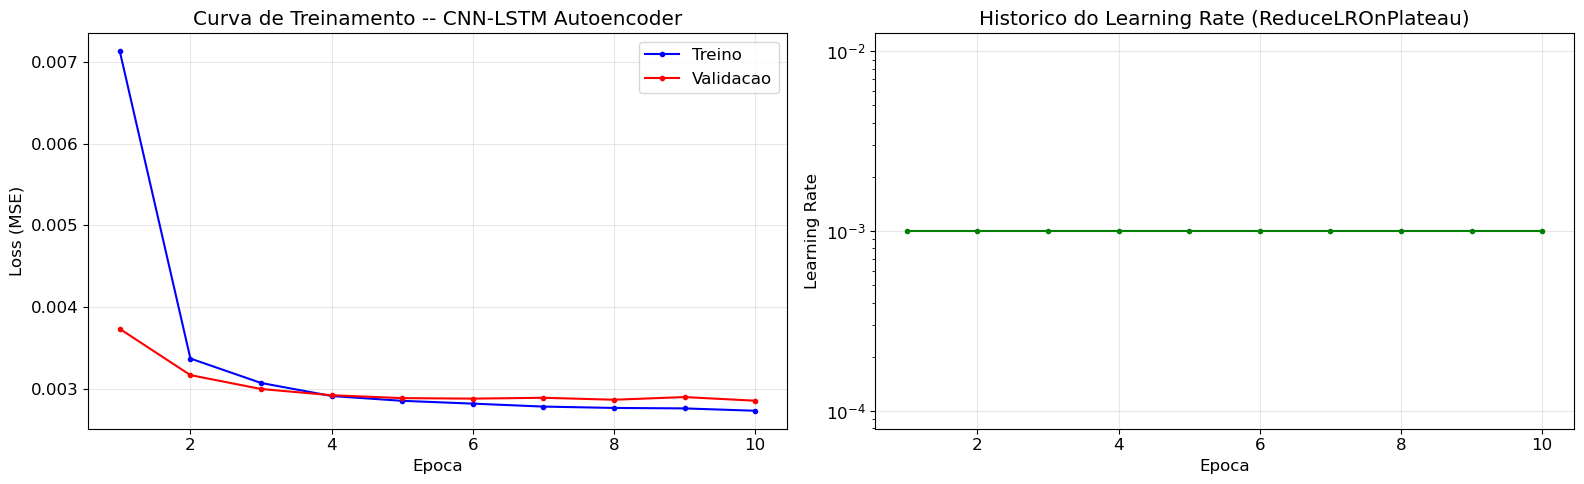

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(range(1, len(train_losses) + 1), train_losses, 'b-o',
        markersize=3, label='Treino')
ax1.plot(range(1, len(val_losses) + 1), val_losses, 'r-o',
        markersize=3, label='Validacao')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Curva de Treinamento -- CNN-LSTM Autoencoder')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(lr_history) + 1), lr_history, 'g-o', markersize=3)
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Historico do Learning Rate (ReduceLROnPlateau)')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Deteccao de Anomalias

Calculo do erro de reconstrucao (MSE por janela) e definicao dos limiares de deteccao.
Os thresholds sao definidos como o **percentil 95** e o **percentil 99** do erro de
reconstrucao calculado sobre as **janelas saudaveis de validacao**.

**Melhoria v2**: alem de P95/P99, um threshold otimizado e encontrado via curva
Precision-Recall, maximizando o F1-Score no conjunto de validacao.

In [14]:
def compute_reconstruction_errors(model, dataset, batch_size=256):
    """Calcula o MSE de reconstrucao por janela usando WindowDataset."""
    model.eval()
    errors = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)

    with torch.no_grad():
        for batch_x in loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            mse = ((output - batch_x) ** 2).mean(dim=(1, 2))
            errors.extend(mse.cpu().numpy())

    return np.array(errors)


ds_train_h  = WindowDataset(ga_train, eid_tr[healthy_mask_tr],
                            start_tr[healthy_mask_tr], WINDOW_SIZE)
ds_val_h    = WindowDataset(ga_val, eid_va[healthy_mask_va],
                            start_va[healthy_mask_va], WINDOW_SIZE)
ds_val_all  = WindowDataset(ga_val, eid_va, start_va, WINDOW_SIZE)
ds_test_all = WindowDataset(ga_test, eid_te, start_te, WINDOW_SIZE)

errors_train_healthy = compute_reconstruction_errors(model, ds_train_h)
errors_val_healthy   = compute_reconstruction_errors(model, ds_val_h)
errors_val_all       = compute_reconstruction_errors(model, ds_val_all)
errors_test_all      = compute_reconstruction_errors(model, ds_test_all)

print("Erros de reconstrucao (MSE):")
print(f"  Treino (saudavel)    - media: {errors_train_healthy.mean():.6f}, "
      f"std: {errors_train_healthy.std():.6f}, "
      f"max: {errors_train_healthy.max():.6f}")
print(f"  Validacao (saudavel) - media: {errors_val_healthy.mean():.6f}, "
      f"std: {errors_val_healthy.std():.6f}, "
      f"max: {errors_val_healthy.max():.6f}")
print(f"  Validacao (completo) - media: {errors_val_all.mean():.6f}")
print(f"  Teste (completo)     - media: {errors_test_all.mean():.6f}")

Erros de reconstrucao (MSE):
  Treino (saudavel)    - media: 0.002735, std: 0.001983, max: 0.027459
  Validacao (saudavel) - media: 0.002850, std: 0.002407, max: 0.023870
  Validacao (completo) - media: 0.007333
  Teste (completo)     - media: 0.006181


In [15]:
threshold_p95 = float(np.percentile(errors_val_healthy, 95))
threshold_p99 = float(np.percentile(errors_val_healthy, 99))

print("Thresholds percentis (baseados nas janelas saudaveis de validacao):")
print(f"  Percentil 95: {threshold_p95:.6f}")
print(f"  Percentil 99: {threshold_p99:.6f}")

Thresholds percentis (baseados nas janelas saudaveis de validacao):
  Percentil 95: 0.008568
  Percentil 99: 0.010233


In [16]:
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_val, errors_val_all)
f1_scores_pr = 2 * (precisions_pr * recalls_pr) / (precisions_pr + recalls_pr + 1e-8)
best_f1_idx = np.argmax(f1_scores_pr)
threshold_best_f1 = float(thresholds_pr[best_f1_idx])

print("Threshold otimizado via curva Precision-Recall (validacao):")
print(f"  Threshold Best-F1: {threshold_best_f1:.6f}")
print(f"  F1 no ponto otimo: {f1_scores_pr[best_f1_idx]:.4f}")
print(f"  Precisao: {precisions_pr[best_f1_idx]:.4f}")
print(f"  Recall:   {recalls_pr[best_f1_idx]:.4f}")

print(f"\nResumo dos 3 thresholds:")
print(f"  P95:      {threshold_p95:.6f}")
print(f"  P99:      {threshold_p99:.6f}")
print(f"  Best-F1:  {threshold_best_f1:.6f}")

Threshold otimizado via curva Precision-Recall (validacao):
  Threshold Best-F1: 0.072578
  F1 no ponto otimo: 0.0446
  Precisao: 0.0409
  Recall:   0.0491

Resumo dos 3 thresholds:
  P95:      0.008568
  P99:      0.010233
  Best-F1:  0.072578


## 10. Avaliacao do Modelo

Avaliacao quantitativa nos conjuntos de teste e validacao utilizando os 3 limiares
(P95, P99, Best-F1). Metricas reportadas: F1-Score, Acuracia, Precisao, Recall,
AUC-ROC e AUC-PR.

**Melhoria v2**: metricas AUC independentes de threshold e avaliacao com 3 limiares.

In [17]:
def evaluate_threshold(errors, y_true, threshold, threshold_name):
    """Avalia metricas de classificacao para um dado threshold."""
    y_pred = (errors > threshold).astype(int)

    f1 = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f"\n{'=' * 55}")
    print(f"  Threshold: {threshold_name} = {threshold:.6f}")
    print(f"{'=' * 55}")
    print(f"  Acuracia:   {acc:.4f}")
    print(f"  Precisao:   {prec:.4f}")
    print(f"  Recall:     {rec:.4f}")
    print(f"  F1-Score:   {f1:.4f}")
    print(f"  Predicoes positivas: {y_pred.sum()} / {len(y_pred)}")
    print(f"  VP: {((y_pred == 1) & (y_true == 1)).sum()}  |  "
          f"FP: {((y_pred == 1) & (y_true == 0)).sum()}  |  "
          f"FN: {((y_pred == 0) & (y_true == 1)).sum()}  |  "
          f"VN: {((y_pred == 0) & (y_true == 0)).sum()}")

    return {'threshold': threshold_name, 'value': float(threshold),
            'f1': float(f1), 'accuracy': float(acc),
            'precision': float(prec), 'recall': float(rec)}


auc_roc_test = roc_auc_score(y_test, errors_test_all)
auc_pr_test  = average_precision_score(y_test, errors_test_all)
auc_roc_val  = roc_auc_score(y_val, errors_val_all)
auc_pr_val   = average_precision_score(y_val, errors_val_all)

print("METRICAS INDEPENDENTES DE THRESHOLD")
print("=" * 55)
print(f"  Teste     - AUC-ROC: {auc_roc_test:.4f} | AUC-PR: {auc_pr_test:.4f}")
print(f"  Validacao - AUC-ROC: {auc_roc_val:.4f} | AUC-PR: {auc_pr_val:.4f}")

print("\n\nAVALIACAO NO CONJUNTO DE TESTE")
print("=" * 55)
metrics_test_p95 = evaluate_threshold(errors_test_all, y_test, threshold_p95,
                                      'Percentil 95')
metrics_test_p99 = evaluate_threshold(errors_test_all, y_test, threshold_p99,
                                      'Percentil 99')
metrics_test_bf1 = evaluate_threshold(errors_test_all, y_test, threshold_best_f1,
                                      'Best-F1')

print("\n\nAVALIACAO NO CONJUNTO DE VALIDACAO")
print("=" * 55)
metrics_val_p95 = evaluate_threshold(errors_val_all, y_val, threshold_p95,
                                     'Percentil 95')
metrics_val_p99 = evaluate_threshold(errors_val_all, y_val, threshold_p99,
                                     'Percentil 99')
metrics_val_bf1 = evaluate_threshold(errors_val_all, y_val, threshold_best_f1,
                                     'Best-F1')

METRICAS INDEPENDENTES DE THRESHOLD
  Teste     - AUC-ROC: 0.6591 | AUC-PR: 0.1833
  Validacao - AUC-ROC: 0.5696 | AUC-PR: 0.0191


AVALIACAO NO CONJUNTO DE TESTE

  Threshold: Percentil 95 = 0.008568
  Acuracia:   0.7785
  Precisao:   0.1598
  Recall:     0.3462
  F1-Score:   0.2186
  Predicoes positivas: 92492 / 476838
  VP: 14779  |  FP: 77713  |  FN: 27914  |  VN: 356432

  Threshold: Percentil 99 = 0.010233
  Acuracia:   0.8318
  Precisao:   0.2084
  Recall:     0.3140
  F1-Score:   0.2505
  Predicoes positivas: 64331 / 476838
  VP: 13405  |  FP: 50926  |  FN: 29288  |  VN: 383219

  Threshold: Best-F1 = 0.072578
  Acuracia:   0.9074
  Precisao:   0.0719
  Recall:     0.0029
  F1-Score:   0.0056
  Predicoes positivas: 1724 / 476838
  VP: 124  |  FP: 1600  |  FN: 42569  |  VN: 432545


AVALIACAO NO CONJUNTO DE VALIDACAO

  Threshold: Percentil 95 = 0.008568
  Acuracia:   0.8220
  Precisao:   0.0153
  Recall:     0.2718
  F1-Score:   0.0290
  Predicoes positivas: 82708 / 476577
  VP

## 10.1 Avaliacao por Evento de Anomalia

**Melhoria v2**: para cada evento de anomalia presente no conjunto de teste, calcula-se
a taxa de deteccao (porcentagem de janelas anomalas que foram corretamente classificadas
como anomalia pelo modelo). Isso fornece uma visao mais pratica de quantas falhas reais
o modelo consegue detectar.

In [19]:
anomaly_event_ids = set(event_info[event_info['event_label'] == 'anomaly']['event_id'].values)

def evaluate_per_event(errors, eids, y_true, threshold, threshold_name):
    """Avalia taxa de deteccao por evento de anomalia."""
    results = []
    for eid in sorted(anomaly_event_ids):
        mask = (eids == eid)
        if mask.sum() == 0:
            continue
        event_errors = errors[mask]
        event_labels = y_true[mask]
        anom_mask = event_labels == 1
        if anom_mask.sum() == 0:
            continue
        n_anom = int(anom_mask.sum())
        detected = int((event_errors[anom_mask] > threshold).sum())
        detection_rate = detected / n_anom
        results.append({
            'event_id': int(eid),
            'n_anom_windows': n_anom,
            'detected': detected,
            'detection_rate': detection_rate
        })

    if not results:
        print(f"  Nenhum evento de anomalia encontrado no split.")
        return results

    df_res = pd.DataFrame(results)
    print(f"\nAvaliacao por evento -- Threshold: {threshold_name} = {threshold:.6f}")
    print(f"{'=' * 65}")
    print(f"{'Evento':>8s} | {'Janelas Anom':>13s} | {'Detectadas':>11s} | {'Taxa Deteccao':>14s}")
    print(f"{'-' * 65}")
    for _, r in df_res.iterrows():
        print(f"{int(r['event_id']):>8d} | {int(r['n_anom_windows']):>13d} | "
              f"{int(r['detected']):>11d} | {r['detection_rate']:>13.1%}")
    print(f"{'-' * 65}")
    avg_rate = df_res['detection_rate'].mean()
    weighted_rate = df_res['detected'].sum() / df_res['n_anom_windows'].sum()
    print(f"  Media (por evento):     {avg_rate:.1%}")
    print(f"  Media (ponderada):      {weighted_rate:.1%}")
    print(f"  Eventos com deteccao>0: {(df_res['detection_rate'] > 0).sum()}/{len(df_res)}")
    return results


print("AVALIACAO POR EVENTO -- CONJUNTO DE TESTE")
event_results_p95 = evaluate_per_event(errors_test_all, eid_te, y_test,
                                        threshold_p95, 'P95')
event_results_bf1 = evaluate_per_event(errors_test_all, eid_te, y_test,
                                        threshold_best_f1, 'Best-F1')

AVALIACAO POR EVENTO -- CONJUNTO DE TESTE

Avaliacao por evento -- Threshold: P95 = 0.008568
  Evento |  Janelas Anom |  Detectadas |  Taxa Deteccao
-----------------------------------------------------------------
       4 |          2772 |         173 |          6.2%
       9 |          3037 |         628 |         20.7%
      11 |          3192 |        3192 |        100.0%
      12 |          1554 |         930 |         59.8%
      16 |          2195 |        1885 |         85.9%
      18 |           611 |          54 |          8.8%
      30 |          3298 |        2904 |         88.1%
      33 |          2916 |        1223 |         41.9%
      35 |           919 |           0 |          0.0%
      39 |           770 |         529 |         68.7%
      44 |          9470 |         935 |          9.9%
      47 |           748 |         733 |         98.0%
      55 |          2508 |         117 |          4.7%
      70 |          2937 |         268 |          9.1%
      78 |     

## 11. Visualizacoes

1. Curva de treinamento (loss)
2. Erro de reconstrucao ao longo do tempo com thresholds
3. Distribuicao dos erros (histograma)
4. Curva ROC
5. Curva Precision-Recall

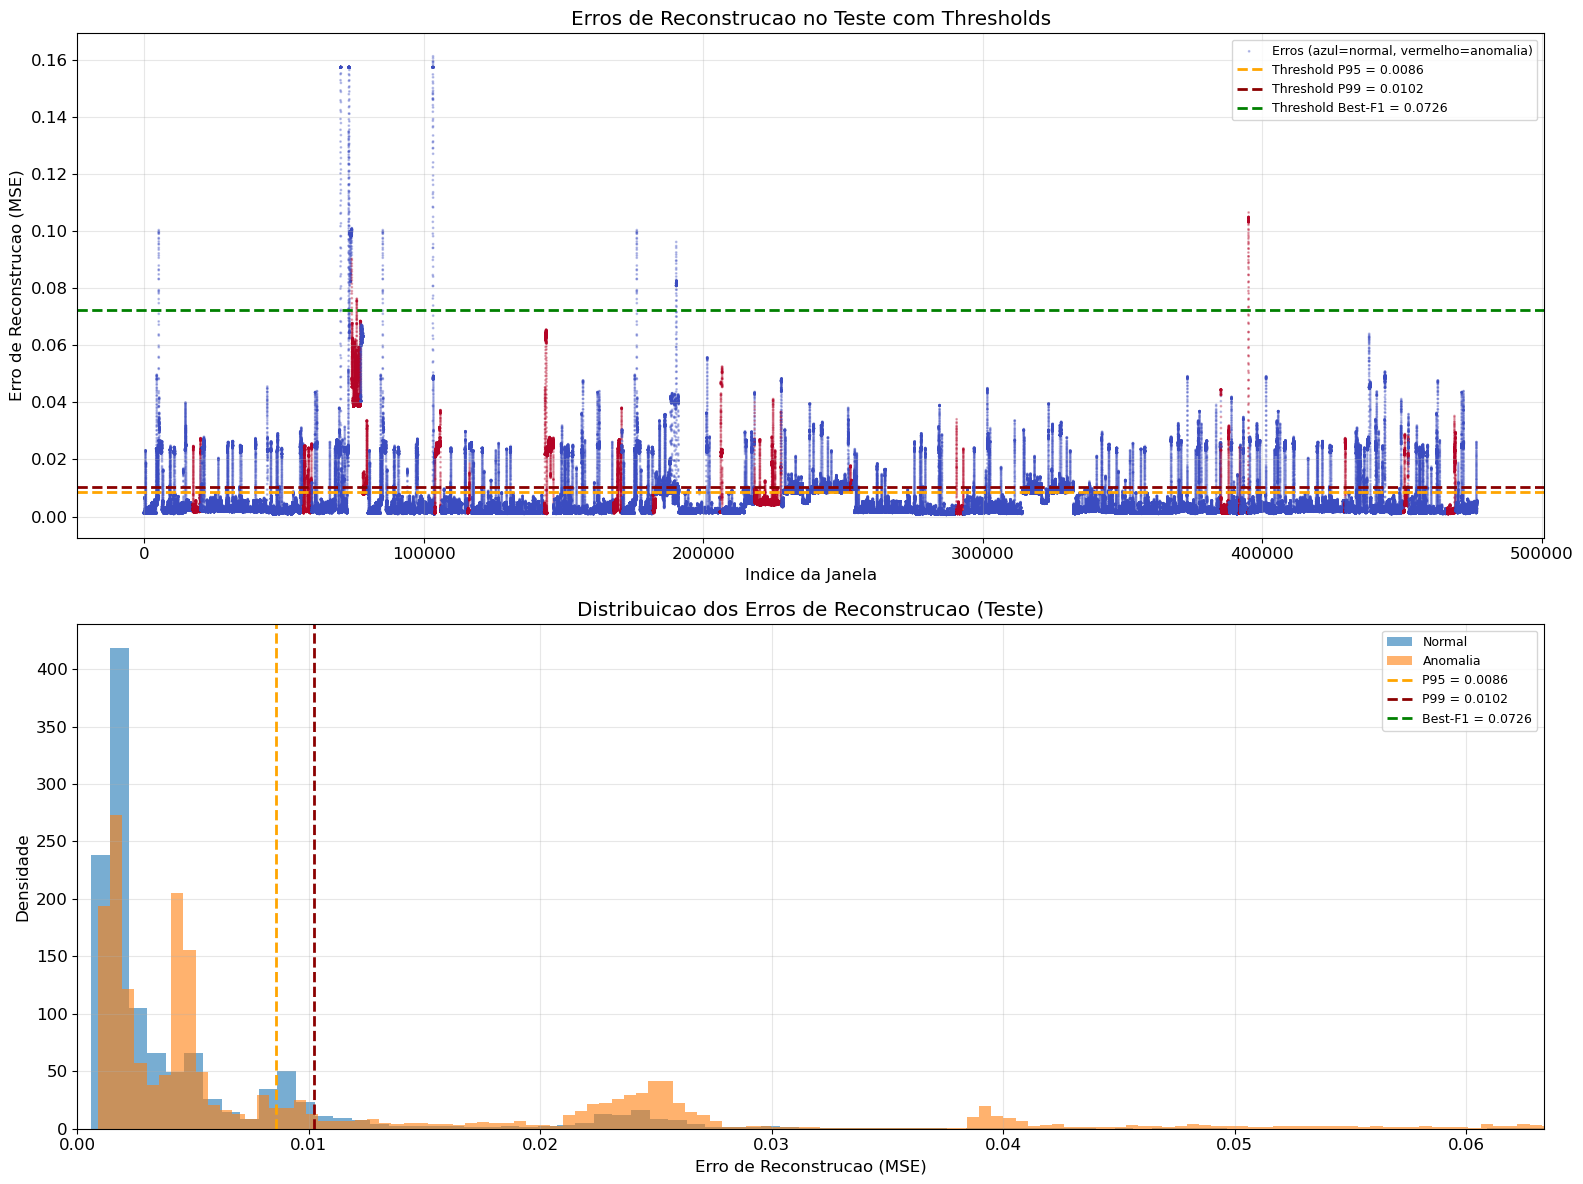

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax = axes[0]
ax.scatter(range(len(errors_test_all)), errors_test_all, c=y_test, cmap='coolwarm',
           s=1, alpha=0.3, label='Erros (azul=normal, vermelho=anomalia)')
ax.axhline(y=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold P95 = {threshold_p95:.4f}')
ax.axhline(y=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'Threshold P99 = {threshold_p99:.4f}')
ax.axhline(y=threshold_best_f1, color='green', linestyle='--', linewidth=2,
           label=f'Threshold Best-F1 = {threshold_best_f1:.4f}')
ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Erro de Reconstrucao (MSE)')
ax.set_title('Erros de Reconstrucao no Teste com Thresholds')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(errors_test_all[y_test == 0], bins=200, alpha=0.6, label='Normal', density=True)
ax.hist(errors_test_all[y_test == 1], bins=200, alpha=0.6, label='Anomalia', density=True)
ax.axvline(x=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'P95 = {threshold_p95:.4f}')
ax.axvline(x=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'P99 = {threshold_p99:.4f}')
ax.axvline(x=threshold_best_f1, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1:.4f}')
ax.set_xlabel('Erro de Reconstrucao (MSE)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos Erros de Reconstrucao (Teste)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(errors_test_all, 99.5))

plt.tight_layout()
plt.show()

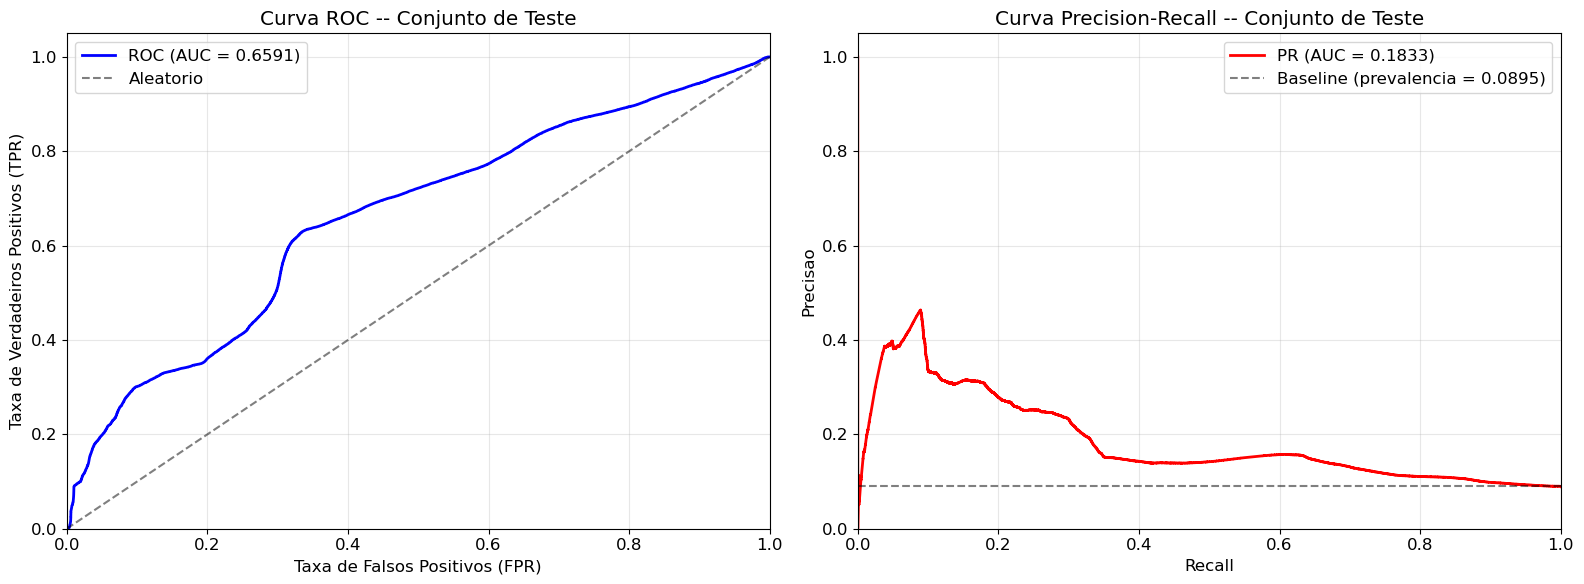

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

fpr, tpr, _ = roc_curve(y_test, errors_test_all)
roc_auc_val_plot = auc(fpr, tpr)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc_val_plot:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax1.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax1.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax1.set_title('Curva ROC -- Conjunto de Teste')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

prec_test, rec_test, _ = precision_recall_curve(y_test, errors_test_all)
pr_auc_val_plot = auc(rec_test, prec_test)
ax2.plot(rec_test, prec_test, 'r-', linewidth=2,
         label=f'PR (AUC = {pr_auc_val_plot:.4f})')
baseline = y_test.sum() / len(y_test)
ax2.axhline(y=baseline, color='k', linestyle='--', alpha=0.5,
            label=f'Baseline (prevalencia = {baseline:.4f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisao')
ax2.set_title('Curva Precision-Recall -- Conjunto de Teste')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

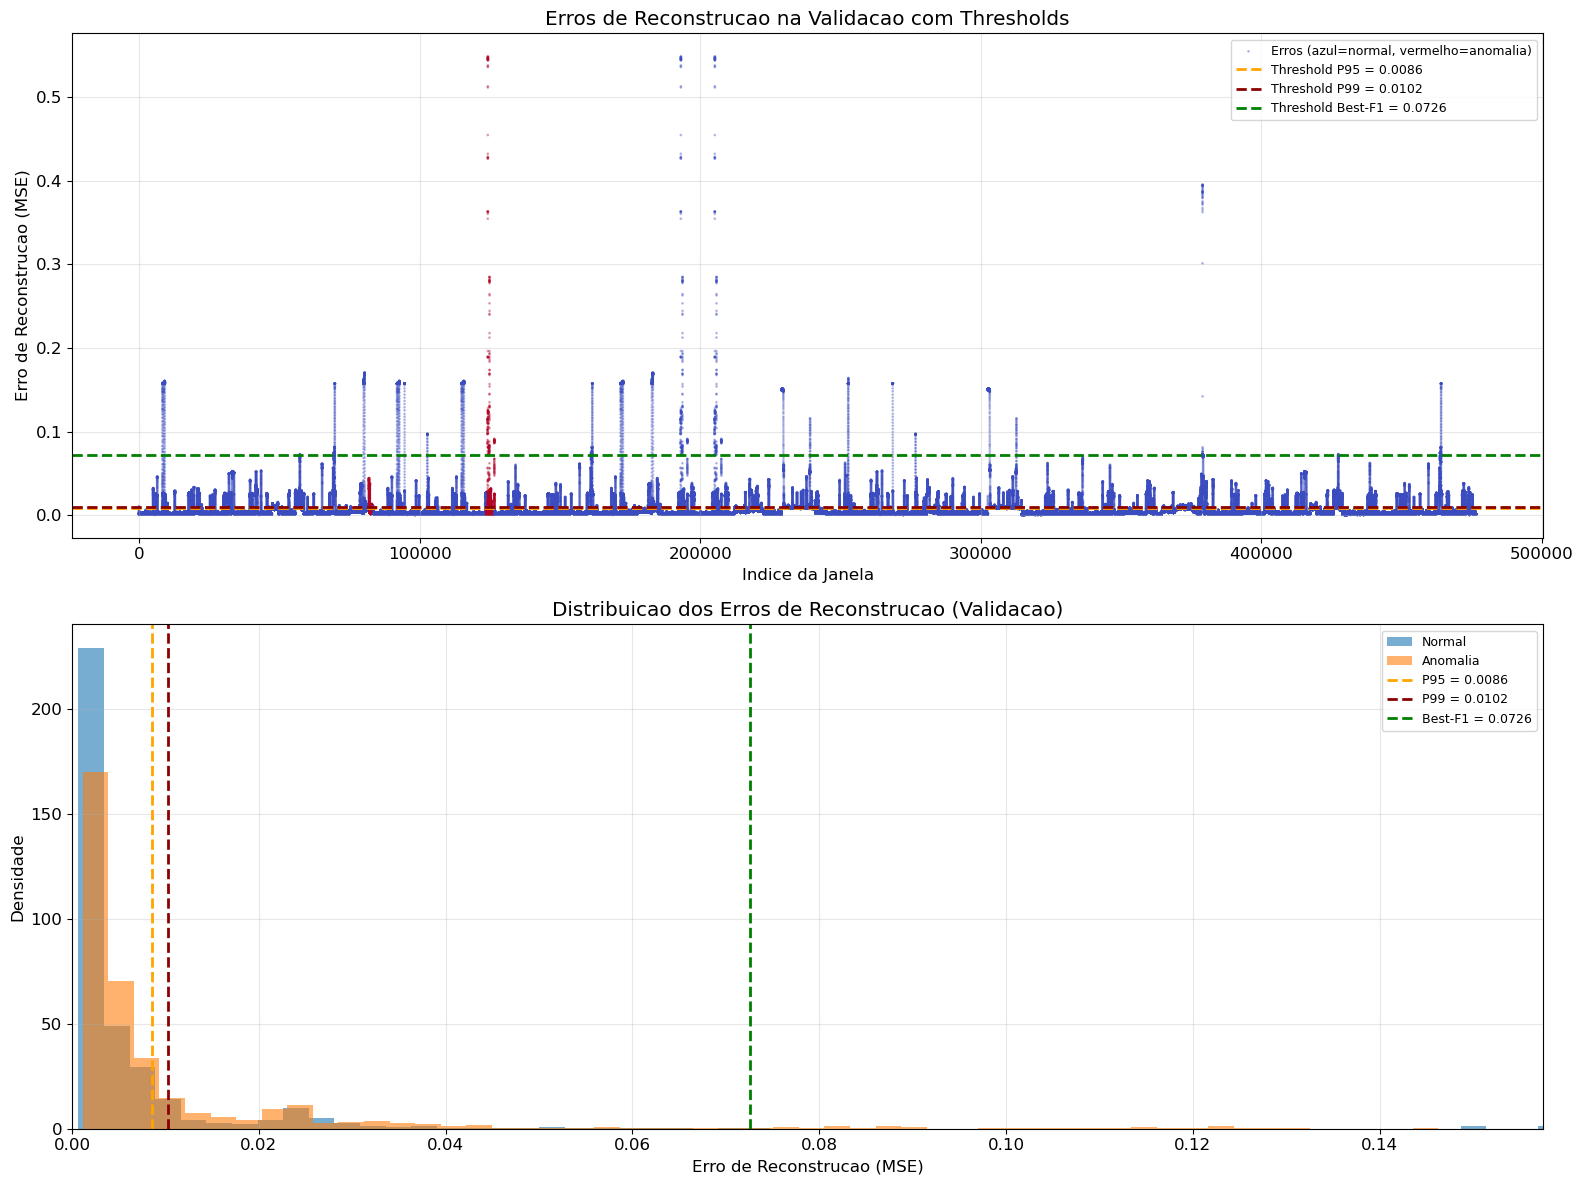

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

ax = axes[0]
ax.scatter(range(len(errors_val_all)), errors_val_all, c=y_val, cmap='coolwarm',
           s=1, alpha=0.3, label='Erros (azul=normal, vermelho=anomalia)')
ax.axhline(y=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'Threshold P95 = {threshold_p95:.4f}')
ax.axhline(y=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'Threshold P99 = {threshold_p99:.4f}')
ax.axhline(y=threshold_best_f1, color='green', linestyle='--', linewidth=2,
           label=f'Threshold Best-F1 = {threshold_best_f1:.4f}')
ax.set_xlabel('Indice da Janela')
ax.set_ylabel('Erro de Reconstrucao (MSE)')
ax.set_title('Erros de Reconstrucao na Validacao com Thresholds')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(errors_val_all[y_val == 0], bins=200, alpha=0.6, label='Normal', density=True)
ax.hist(errors_val_all[y_val == 1], bins=200, alpha=0.6, label='Anomalia', density=True)
ax.axvline(x=threshold_p95, color='orange', linestyle='--', linewidth=2,
           label=f'P95 = {threshold_p95:.4f}')
ax.axvline(x=threshold_p99, color='darkred', linestyle='--', linewidth=2,
           label=f'P99 = {threshold_p99:.4f}')
ax.axvline(x=threshold_best_f1, color='green', linestyle='--', linewidth=2,
           label=f'Best-F1 = {threshold_best_f1:.4f}')
ax.set_xlabel('Erro de Reconstrucao (MSE)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuicao dos Erros de Reconstrucao (Validacao)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, np.percentile(errors_val_all, 99.5))

plt.tight_layout()
plt.show()

## 12. Salvamento de Artefatos

Salvamento do modelo treinado, scaler de normalizacao, lista de features selecionadas
e thresholds para uso posterior em producao ou analises futuras.

In [23]:
model_path = os.path.join(OUTPUT_DIR, 'modelo_cnn_lstm_autoencoder.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'n_features': n_features,
    'timesteps': WINDOW_SIZE,
    'architecture': 'CNNLSTMAutoencoder',
    'best_val_loss': best_val_loss,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'lr_history': lr_history,
    'dropout_rate': DROPOUT_RATE,
}, model_path)
print(f"Modelo salvo: {model_path}")

scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler salvo: {scaler_path}")

features_path = os.path.join(OUTPUT_DIR, 'features_selecionadas.json')
with open(features_path, 'w') as f:
    json.dump({
        'selected_features': selected_features,
        'n_original_features': len(sensor_cols),
        'n_selected_features': len(selected_features),
        'selection_method': 'XGBoost top 30% (com scale_pos_weight)',
    }, f, indent=2, ensure_ascii=False)
print(f"Features salvas: {features_path}")

thresholds_path = os.path.join(OUTPUT_DIR, 'thresholds.json')
with open(thresholds_path, 'w') as f:
    json.dump({
        'threshold_p95': threshold_p95,
        'threshold_p99': threshold_p99,
        'threshold_best_f1': threshold_best_f1,
        'computed_on': 'janelas saudaveis de validacao (P95/P99) e curva PR de validacao (Best-F1)',
        'metrics_teste_p95': metrics_test_p95,
        'metrics_teste_p99': metrics_test_p99,
        'metrics_teste_best_f1': metrics_test_bf1,
        'auc_roc_test': auc_roc_test,
        'auc_pr_test': auc_pr_test,
        'auc_roc_val': auc_roc_val,
        'auc_pr_val': auc_pr_val,
    }, f, indent=2, ensure_ascii=False)
print(f"Thresholds salvos: {thresholds_path}")

print(f"\nArtefatos salvos no diretorio: {os.path.abspath(OUTPUT_DIR)}/")

Modelo salvo: artefatos_v2\modelo_cnn_lstm_autoencoder.pth
Scaler salvo: artefatos_v2\scaler.pkl
Features salvas: artefatos_v2\features_selecionadas.json
Thresholds salvos: artefatos_v2\thresholds.json

Artefatos salvos no diretorio: c:\Users\tibis\OneDrive\Desktop\IC_WIND_THIAGO\artefatos_v2/


## Conclusao

Este notebook (v2) implementou um pipeline melhorado de deteccao de anomalias em turbinas
eolicas utilizando dados SCADA do Wind Farm C:

1. **Pre-processamento**: forward fill de valores ausentes e normalizacao Min-Max (sem clipping)
2. **Selecao de features**: XGBoost com `scale_pos_weight` para lidar com desbalanceamento
3. **Modelo**: CNN-LSTM Autoencoder com dropout=0.15 (reduzido de 0.5)
4. **Treinamento**: batch size=128, scheduler ReduceLROnPlateau para convergencia adaptativa
5. **Deteccao**: thresholds P95, P99 e otimizado via curva Precision-Recall
6. **Avaliacao**: F1, Acuracia, Precisao, Recall, AUC-ROC, AUC-PR + avaliacao por evento

### Melhorias em relacao a v1
- Dropout reduzido preserva melhor a capacidade de reconstrucao do autoencoder
- Batch size maior acelera o treinamento significativamente
- Scheduler adapta o learning rate automaticamente quando o loss estagna
- scale_pos_weight no XGBoost melhora a selecao de features em cenario desbalanceado
- Threshold otimizado via curva PR tende a superar os percentis fixos
- Metricas AUC avaliam o modelo independente da escolha de threshold
- Avaliacao por evento mostra o impacto pratico da deteccao

Todos os artefatos (modelo, scaler, features, thresholds) foram salvos em `artefatos_v2/`
para reproducibilidade e uso em producao.